In [1]:
import os
import sys
import shutil
import glob

# --- COLAB SETUP ---
try:
    from google.colab import drive
    IN_COLAB = True
    print("Running in Google Colab")

    drive.mount('/content/drive')

    REPO_URL = "https://github.com/zeynepoztunc/aml-procedural-mistake-detection.git"
    BRANCH = "emre-second-step"

    if not os.path.exists('/content/code'):
        !git clone --recursive {REPO_URL} /content/code
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
    else:
        os.chdir('/content/code')
        !git fetch origin {BRANCH}
        !git checkout {BRANCH}
        !git pull origin {BRANCH}

    if '/content/code' not in sys.path:
        sys.path.append('/content/code')

    !pip install -q transformers scipy torch-geometric networkx

    # --- DATA SETUP ---
    DRIVE_BASE = "/content/drive/MyDrive/AML_Project"

    # Extract annotations from 1s.zip if needed
    data_zip = f"{DRIVE_BASE}/1s.zip"
    if not os.path.exists("annotations/annotation_json/step_annotations.json"):
        if os.path.exists(data_zip):
            print("Extracting annotations from 1s.zip...")
            !mkdir -p data
            !unzip -q -n "{data_zip}" -d data
            if os.path.exists("data/1s/annotations"):
                !cp -r data/1s/annotations .
            if os.path.exists("data/1s"):
                !rm -rf data/1s
            print("Annotations extracted.")

    # Copy step1 output from Drive if exists
    os.makedirs("extension_data", exist_ok=True)
    DRIVE_STEP1_OUTPUT = f"{DRIVE_BASE}/extension_data/step_embeddings_gt.pkl"
    LOCAL_STEP1_OUTPUT = "extension_data/step_embeddings_gt.pkl"

    if os.path.exists(DRIVE_STEP1_OUTPUT) and not os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Copying step1 output from Drive...")
        !cp "{DRIVE_STEP1_OUTPUT}" "{LOCAL_STEP1_OUTPUT}"
        print("Done!")
    elif os.path.exists(LOCAL_STEP1_OUTPUT):
        print("Step1 output already exists locally.")
    else:
        print("WARNING: Step1 output not found. Run extension_step1 first!")

except ImportError:
    IN_COLAB = False
    print("Not running in Colab")

Running in Google Colab
Mounted at /content/drive
Cloning into '/content/code'...
remote: Enumerating objects: 952, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 952 (delta 118), reused 112 (delta 96), pack-reused 786 (from 2)
Receiving objects: 100% (952/952), 97.86 MiB | 18.05 MiB/s, done.
Resolving deltas: 100% (508/508), done.
Submodule 'annotations' (https://github.com/CaptainCook4D/annotations) registered for path 'annotations'
Cloning into '/content/code/annotations'...
remote: Enumerating objects: 152, done.        
remote: Counting objects: 100% (152/152), done.        
remote: Compressing objects: 100% (98/98), done.        
remote: Total 152 (delta 75), reused 108 (delta 46), pack-reused 0 (from 0)        
Receiving objects: 100% (152/152), 793.14 KiB | 1.89 MiB/s, done.
Resolving deltas: 100% (75/75), done.
Submodule path 'annotations': checked out '0e9a108be2cbcbcbd592e7418c0ab9c16232d27a'
From https://

In [2]:
import json
import pickle
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 1. Load Data and Task Graphs

In [3]:
# Load processed step embeddings from Substep 1.
#
# Substep 1 writes one file per boundary source and both are loaded here, so the whole
# notebook runs once and produces a realized graph set for each:
#
# 'gt'           - step boundaries from the annotations. These are an oracle: the
#                  annotation lists only the steps that were actually performed, so the
#                  number of segments is itself informative about the label.
# 'actionformer' - boundaries from an ActionFormer checkpoint trained on our EgoVLP 1s
#                  features (rohithpeddi/actionformer_release, the CaptainCook4D fork).
#                  Here the segment count comes from a detector, so a missed detection and
#                  a genuinely skipped step look the same.
#
# Everything downstream is computed per source; PRIMARY_SOURCE names the one used for
# the single-graph illustrations and the encoder diagnostic.

_SOURCE_FILES = {'gt': 'step_embeddings_gt.pkl',
                 'actionformer': 'step_embeddings_actionformer.pkl'}


def _resolve(filename):
    """Prefer the Drive copy in Colab, fall back to the local extension_data folder."""
    if IN_COLAB:
        drive = "/content/drive/MyDrive/AML_Project/extension_data/" + filename
        if os.path.exists(drive):
            return drive
    local = os.path.join("extension_data", filename)
    return local if os.path.exists(local) else None


SOURCE_DATA, SOURCE_SPLITS = {}, {}
for _source, _filename in _SOURCE_FILES.items():
    _path = _resolve(_filename)
    if _path is None:
        print(f"  {_source:<14} not found ({_filename}) - skipped")
        continue
    with open(_path, 'rb') as f:
        _loaded = pickle.load(f)
    SOURCE_DATA[_source] = _loaded['data']
    SOURCE_SPLITS[_source] = _loaded['splits']
    print(f"  {_source:<14} {len(_loaded['data']):>3} recordings   {_path}")

assert SOURCE_DATA, "No step embeddings found. Run extension_step1_actionformer.ipynb first."

SOURCES = list(SOURCE_DATA)
PRIMARY_SOURCE = 'gt' if 'gt' in SOURCE_DATA else SOURCES[0]
processed_data = SOURCE_DATA[PRIMARY_SOURCE]
splits = SOURCE_SPLITS[PRIMARY_SOURCE]
print(f"\nSources: {SOURCES}   primary: {PRIMARY_SOURCE}")

# Load step annotations for textual descriptions
with open('annotations/annotation_json/step_annotations.json', 'r') as f:
    step_annotations = json.load(f)


  gt             384 recordings   /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_gt.pkl
  actionformer   384 recordings   /content/drive/MyDrive/AML_Project/extension_data/step_embeddings_actionformer.pkl

Sources: ['gt', 'actionformer']   primary: gt


In [4]:
# Task graph annotations (from CaptainCook4D).
#
# The dataset ships one task graph per recipe in annotations/task_graphs/, and these are
# genuine DAGs: preparation steps that may happen in any order sit on parallel branches
# and merge at the step that consumes them. Across the 24 recipes, 18 contain a
# branching node, 23 contain a merge, and 20 have more than one root, so the topology
# carries real procedural information that a linear ordering does not.
#
# The files are keyed by recipe name and number their steps locally (0 = START,
# last = END), while every other annotation file keys steps by a global step_id. The two
# are reconciled here on the step descriptions, which are byte-identical in both sources.

import glob
import re

TASK_GRAPH_DIR = "annotations/task_graphs"


def _norm_description(text):
    return re.sub(r'[^a-z0-9]', '', text.lower())


def load_captaincook_task_graphs(step_annotations, graph_dir=TASK_GRAPH_DIR):
    """Load the shipped per-recipe DAGs and re-key them by activity id.

    Returns None if any recipe fails to match a file, so that the caller falls back
    visibly rather than silently mixing two different graph definitions.
    """
    files = sorted(glob.glob(os.path.join(graph_dir, "*.json")))
    if not files:
        return None

    parsed = []
    for path in files:
        with open(path, 'r') as f:
            raw = json.load(f)
        steps = {k: v for k, v in raw['steps'].items() if v not in ('START', 'END')}
        parsed.append((os.path.basename(path)[:-5], steps, raw['edges']))

    # global step_id -> description, per activity, taken from the annotations
    annotated = defaultdict(dict)
    for recording_id, ann in step_annotations.items():
        activity = recording_id.split('_')[0]
        for step in ann.get('steps', []):
            sid, desc = step.get('step_id'), step.get('description', '')
            if sid and desc:
                annotated[activity].setdefault(sid, desc)

    graphs = {}
    for activity, id_to_desc in annotated.items():
        global_of_norm = {_norm_description(d): sid for sid, d in id_to_desc.items()}

        best = (0.0, None)
        for name, steps, edges in parsed:
            overlap = (sum(1 for v in steps.values()
                           if _norm_description(v) in global_of_norm)
                       / max(1, len(id_to_desc)))
            if overlap > best[0]:
                best = (overlap, (name, steps, edges))

        if best[0] < 0.9:
            print(f"  activity {activity}: no task graph matched (best overlap {best[0]:.2f})")
            return None

        name, steps, raw_edges = best[1]
        global_of_local = {k: global_of_norm[_norm_description(v)] for k, v in steps.items()}

        # A few recipes list the same step twice (a stir repeated later in the
        # procedure). The annotations give both occurrences one step_id, so they are one
        # canonical node here and the two occurrences' edges are unioned onto it.
        global_ids = sorted(set(global_of_local.values()))
        index_of_global = {gid: i for i, gid in enumerate(global_ids)}
        index_of_local = {local: index_of_global[gid] for local, gid in global_of_local.items()}
        description_of_global = {gid: steps[local] for local, gid in global_of_local.items()}

        seen, edges = set(), []
        for a, b in raw_edges:
            a, b = str(a), str(b)
            # Edges touching START/END are dropped: those have no visual counterpart.
            if a not in index_of_local or b not in index_of_local:
                continue
            src, dst = index_of_local[a], index_of_local[b]
            if src == dst or (src, dst) in seen:
                continue
            seen.add((src, dst))
            edges.append({'from': src, 'to': dst})

        graphs[activity] = {
            'recipe_id': activity,
            'source_file': name,
            'nodes': [{'step_id': gid, 'description': description_of_global[gid], 'index': i}
                      for i, gid in enumerate(global_ids)],
            'edges': edges,
        }

    return graphs


task_graphs = load_captaincook_task_graphs(step_annotations)

if task_graphs is not None:
    _n_nodes = sum(len(g['nodes']) for g in task_graphs.values())
    _n_edges = sum(len(g['edges']) for g in task_graphs.values())
    print(f"Loaded {len(task_graphs)} task graphs from {TASK_GRAPH_DIR}")
    print(f"  {_n_nodes} nodes, {_n_edges} edges; a linear chain over the same nodes "
          f"would have {_n_nodes - len(task_graphs)}")

    # The recipe -> graph assignment is made independently per activity by description
    # overlap, so two activities could in principle claim the same file. They must not:
    # one graph per recipe, 24 recipes, 24 distinct files.
    _files = [g['source_file'] for g in task_graphs.values()]
    assert len(task_graphs) == 24, (
        f"Expected 24 recipes, resolved {len(task_graphs)}")
    assert len(set(_files)) == len(_files), (
        "Two activities matched the same task-graph file: "
        f"{sorted(f for f in set(_files) if _files.count(f) > 1)}")
    print(f"  {len(set(_files))} distinct graph files for {len(task_graphs)} recipes")
else:
    print(f"No usable task graphs under {TASK_GRAPH_DIR}.")


Loaded 24 task graphs from annotations/task_graphs
  353 nodes, 369 edges; a linear chain over the same nodes would have 329
  24 distinct graph files for 24 recipes


In [5]:
# The CaptainCook4D DAGs are required; there is no acceptable substitute.
#
# This cell used to fall back to a linear chain over step_id order whenever the shipped
# graphs failed to load. step_id order is NOT dependency order, so that chain is not the
# recipe's procedural structure - and nothing about the failure is visible downstream: the
# run still writes plausible .pkl files and Substep 4 still trains, on the wrong topology.
# The spec is explicit that this substep uses "the ground truth task graphs provided by
# CaptainCook4D", so an unresolved graph is now a hard error.
#
# The builder below is kept as a debugging utility. No reported result may come from it.

ALLOW_LINEAR_FALLBACK = False      # debugging only - never for a reported number


def build_task_graphs_from_annotations(step_annotations):
    """
    Build task graphs from step annotations.
    Each recipe type (activity_id) has a canonical set of steps.

    Note: activity_id is extracted from recording_id prefix (format: X_Y where X is activity/recipe number)
    """
    recipe_steps = defaultdict(dict)

    for recording_id, ann in step_annotations.items():
        # Extract recipe_id from recording_id prefix (format: "X_Y" where X is activity number)
        recipe_id = recording_id.split('_')[0] if '_' in recording_id else 'unknown'

        for step in ann.get('steps', []):
            step_id = step.get('step_id')
            description = step.get('description', '')

            if step_id and description:
                # Keep the most common/complete description
                if step_id not in recipe_steps[recipe_id]:
                    recipe_steps[recipe_id][step_id] = description

    # Convert to task graph format
    task_graphs = {}
    for recipe_id, steps in recipe_steps.items():
        sorted_steps = sorted(steps.items(), key=lambda x: x[0])

        task_graphs[recipe_id] = {
            'recipe_id': recipe_id,
            'nodes': [
                {'step_id': sid, 'description': desc, 'index': i}
                for i, (sid, desc) in enumerate(sorted_steps)
            ],
            'edges': [
                {'from': i, 'to': i+1}
                for i in range(len(sorted_steps) - 1)
            ]
        }

    return task_graphs

if task_graphs is None:
    if not ALLOW_LINEAR_FALLBACK:
        raise RuntimeError(
            f"CaptainCook4D task graphs could not be resolved from {TASK_GRAPH_DIR}. "
            "Substep 3 requires the shipped DAGs - check that the `annotations` submodule "
            "is initialised (git submodule update --init). Set ALLOW_LINEAR_FALLBACK = True "
            "to debug with a linear chain, but never to produce a reported result.")
    print("WARNING: linear-chain fallback in use. The topology below is NOT the "
          "dataset's procedural structure and must not be reported.")
    task_graphs = build_task_graphs_from_annotations(step_annotations)

_edge_total = sum(len(g["edges"]) for g in task_graphs.values())
print(f"Task graphs for {len(task_graphs)} recipe types, {_edge_total} edges")
for recipe_id, graph in list(task_graphs.items())[:3]:
    print(f"  Recipe {recipe_id}: {len(graph['nodes'])} steps")


Task graphs for 24 recipe types, 369 edges
  Recipe 1: 12 steps
  Recipe 2: 14 steps
  Recipe 3: 14 steps


## 2. EgoVLP Text Encoder (Aligned with Visual Features)

We load the EgoVLP model and use its text encoder.

In [6]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer
import sys
import os
import shutil
import urllib.request

# Determine feature dimension from loaded data
sample_key = list(processed_data.keys())[0]
FEATURE_DIM = processed_data[sample_key]['step_embeddings'].shape[1]
print(f"Visual feature dimension: {FEATURE_DIM}")

# ==============================================================================
# Strict EgoVLP Loading with Helper Checks
# ==============================================================================
EGOVLP_AVAILABLE = False

try:
    # 1. Clone EgoVLP repository directly
    EGOVLP_PATH = "EgoVLP"
    if not os.path.exists(EGOVLP_PATH):
        print("Cloning EgoVLP repository...")
        !git clone https://github.com/showlab/EgoVLP.git {EGOVLP_PATH}

    print("Installing EgoVLP dependencies...")
    # Added 'av', 'decord', and 'ffmpeg-python' to the requirements
    !pip install -q timm ftfy einops av decord ffmpeg-python

    # 2. Add to system path
    if EGOVLP_PATH not in sys.path:
        sys.path.insert(0, EGOVLP_PATH)

    # ==========================================================================
    # Fix for missing ViT backbone
    # ==========================================================================
    # The model code expects 'pretrained/jx_vit_base_p16_224-80ecf9dd.pth' to exist locally
    if not os.path.exists("pretrained"):
        os.makedirs("pretrained")

    vit_checkpoint_path = "pretrained/jx_vit_base_p16_224-80ecf9dd.pth"
    if not os.path.exists(vit_checkpoint_path):
        print(f"Downloading missing ViT backbone to {vit_checkpoint_path}...")
        vit_url = "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-vitjx/jx_vit_base_p16_224-80ecf9dd.pth"
        urllib.request.urlretrieve(vit_url, vit_checkpoint_path)
        print("Download complete.")

    # 3. Locate Main EgoVLP Checkpoint (Drive or Local)
    CKPT_FILENAME = "egovlp.pth"

    # Define paths to search
    search_paths = [
        "pretrained/egovlp.pth",  # Local
        f"/content/drive/MyDrive/AML_Project/pretrained/{CKPT_FILENAME}"  # Drive
    ]

    # Check if we are in Colab to define Drive path creation
    if 'IN_COLAB' in globals() and IN_COLAB:
        DRIVE_PRETRAINED_DIR = "/content/drive/MyDrive/AML_Project/pretrained"
        os.makedirs(DRIVE_PRETRAINED_DIR, exist_ok=True)
        print(f"Ensured directory exists: {DRIVE_PRETRAINED_DIR}")

    # Find the checkpoint
    EGOVLP_CKPT = None
    for path in search_paths:
        if os.path.exists(path):
            EGOVLP_CKPT = path
            print(f"Found checkpoint at: {EGOVLP_CKPT}")
            break

    # If not found, raise helpful error
    if EGOVLP_CKPT is None:
        error_msg = (
            f"\n{'='*60}\n"
            f"CRITICAL: EgoVLP checkpoint '{CKPT_FILENAME}' not found!\n"
            f"{'='*60}\n"
            f"Please follow these steps:\n"
            f"1. Go to the official EgoVLP repo: https://github.com/showlab/EgoVLP\n"
            f"2. Download the 'Ego4D' pretrained model from their Model Zoo.\n"
            f"3. Rename the file to '{CKPT_FILENAME}'.\n"
            f"4. Upload it to this Google Drive folder: /AML_Project/pretrained/\n"
            f"   (Full path: /content/drive/MyDrive/AML_Project/pretrained/{CKPT_FILENAME})\n"
            f"\nAlternatively, you can upload it to the local Colab folder: pretrained/\n"
            f"{'='*60}\n"
        )
        raise FileNotFoundError(error_msg)

    # Check for model module availability
    try:
        from model.model import FrozenInTime
    except ImportError:
            print("Could not import FrozenInTime despite path insertion. Re-checking dependencies...")
            !pip install -q timm ftfy einops av decord ffmpeg-python
            from model.model import FrozenInTime

    # Load EgoVLP config
    egovlp_config = {
        "video_params": {
            "model": "SpaceTimeTransformer",
            "arch_config": "base_patch16_224",
            "num_frames": 16,      # UPDATED: Changed from 4 to 16 to match checkpoint
            "pretrained": False,
            "time_init": "zeros"
        },
        "text_params": {
            "model": "distilbert-base-uncased",
            "pretrained": True,
            "input": "text"
        },
        "projection": "minimal",
        "projection_dim": 256,
        "load_checkpoint": ""  # Bypass internal loading
    }

    # Initialize model
    print("Loading EgoVLP model structure...")

    # Fix for LOCAL_RANK error
    if 'LOCAL_RANK' not in os.environ:
        os.environ['LOCAL_RANK'] = '0'

    egovlp_model = FrozenInTime(**egovlp_config)

    # Load checkpoint manually
    print(f"Loading weights from {EGOVLP_CKPT}...")

    try:
        # Try loading with weights_only=False (needed for older checkpoints with ConfigParser)
        checkpoint = torch.load(EGOVLP_CKPT, map_location='cpu', weights_only=False)
    except TypeError:
        # Fallback for older torch versions without this arg
        checkpoint = torch.load(EGOVLP_CKPT, map_location='cpu')

    state_dict = checkpoint.get('state_dict', checkpoint)

    # Remove 'module.' prefix if present
    new_state_dict = {}
    for k, v in state_dict.items():
        new_key = k.replace('module.', '') if k.startswith('module.') else k
        new_state_dict[new_key] = v

    # strict=False silently leaves any parameter that is ABSENT from the checkpoint at
    # its random initialisation, and prints nothing. The text branch (text_model.* and
    # txt_proj.*) is exactly what this notebook depends on: if txt_proj stayed random,
    # encode_texts() would return a random projection of DistilBERT features, which is
    # not the space the EgoVLP visual features live in, and every cosine similarity
    # computed below would be meaningless. So check what actually loaded.
    load_report = egovlp_model.load_state_dict(new_state_dict, strict=False)
    TEXT_BRANCH_MISSING = [k for k in load_report.missing_keys
                           if k.startswith('text_model') or k.startswith('txt_proj')]
    print(f"Checkpoint load: {len(load_report.missing_keys)} missing key(s), "
          f"{len(load_report.unexpected_keys)} unexpected key(s)")
    if TEXT_BRANCH_MISSING:
        print("*" * 72)
        print(f"WARNING: {len(TEXT_BRANCH_MISSING)} text-branch parameter(s) were NOT in "
              f"the checkpoint and are still randomly initialised:")
        for k in TEXT_BRANCH_MISSING[:10]:
            print(f"    {k}")
        print("Text embeddings are therefore NOT aligned with the visual features.")
        print("*" * 72)
    else:
        print("Text branch (text_model.* + txt_proj.*) fully loaded from the checkpoint.")
    egovlp_model = egovlp_model.to(device)
    egovlp_model.eval()

    EGOVLP_AVAILABLE = True
    print("EgoVLP text encoder loaded successfully!")

    # Initialize tokenizer globally
    print("Loading Tokenizer...")
    tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

except Exception as e:
    print(f"CRITICAL ERROR: Could not load EgoVLP.\n{e}")
    raise RuntimeError("EgoVLP is required but failed to load. Stopping execution.") from e


# ==============================================================================
# Text Encoding Function (EgoVLP Only)
# ==============================================================================

def encode_texts(texts, normalize=True):
    """
    Encode text descriptions using EgoVLP.
    """
    with torch.no_grad():
        # Tokenize text
        inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True)

        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # Compute embeddings
        # Note: EgoVLP compute_text expects the dictionary of inputs directly
        text_embeddings = egovlp_model.compute_text(inputs)

    if normalize:
        text_embeddings = F.normalize(text_embeddings, p=2, dim=-1)

    return text_embeddings


# Test the encoder
print("\nTesting text encoder...")
test_texts = ["Break the eggs", "Mix the ingredients", "Heat the pan"]
with torch.no_grad():
    test_emb = encode_texts(test_texts)
print(f"Test text embeddings shape: {test_emb.shape}")
print(f"Alignment method: EgoVLP (Strict)")

Visual feature dimension: 256
Cloning EgoVLP repository...
Cloning into 'EgoVLP'...
remote: Enumerating objects: 268, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 268 (delta 67), reused 57 (delta 57), pack-reused 182 (from 1)
Receiving objects: 100% (268/268), 1.99 MiB | 16.70 MiB/s, done.
Resolving deltas: 100% (120/120), done.
Installing EgoVLP dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 61.9 MB/s eta 0:00:00
Download complete.
Ensured directory exists: /content/drive/MyDrive/AML_Project/pretrained
Found checkpoint at: /content/drive/MyDrive/AML_Project/pretrained/egovlp.pth
Loading EgoVLP model structure...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]


Testing text encoder...
Test text embeddings shape: torch.Size([3, 256])
Alignment method: EgoVLP (Strict)


In [7]:
# ==============================================================================
# DIAGNOSTIC: is the EgoVLP text encoder really aligned with our visual features?
# ==============================================================================
# Everything in this notebook rests on one assumption: EgoVLP's video and text
# encoders share a joint space, so cosine similarity between a visual step embedding
# and a step description is meaningful. That assumption is measured here, not assumed.
#
# Test: for each recording, encode that recording's OWN step descriptions and match
# them against its OWN visual step embeddings. Step i's video should retrieve step i's
# description. If the two encoders share a space, top-1 accuracy sits far above chance
# and the correct pair scores clearly higher than a wrong pair.

import numpy as np


def _valid_steps(recording_id):
    """Step dicts in the same order Substep 1 used (negative timestamps dropped).

    Substep 1 skips steps with a negative start/end time ("missing steps"), so the raw
    annotation list is NOT index-aligned with step_embeddings. Any code that pairs an
    embedding with a description has to apply the same filter.
    """
    out = []
    for s in step_annotations.get(recording_id, {}).get('steps', []):
        st, et = s.get('start_time'), s.get('end_time')
        if st is None or et is None or float(st) < 0 or float(et) < 0:
            continue
        out.append(s)
    return out


rng = np.random.default_rng(0)
sample_ids = list(processed_data.keys())
rng.shuffle(sample_ids)
sample_ids = sample_ids[:100]

n_used = n_skipped = 0
hits = total = 0
chance_sum = 0.0
self_sims, other_sims = [], []

for rid in sample_ids:
    vis = processed_data[rid]['step_embeddings']
    descs = [s.get('description', '') for s in _valid_steps(rid)]

    # Only usable when descriptions line up 1:1 with the embeddings.
    if len(descs) != len(vis) or len(descs) < 2 or not all(descs):
        n_skipped += 1
        continue
    n_used += 1

    txt = encode_texts(descs, normalize=True).cpu().numpy()
    v = vis / (np.linalg.norm(vis, axis=1, keepdims=True) + 1e-8)
    sim = v @ txt.T                    # (n, n); the diagonal is the correct pairing

    n = len(descs)
    hits += int((sim.argmax(axis=1) == np.arange(n)).sum())
    total += n
    chance_sum += 1.0                  # one expected hit per recording by chance

    eye = np.eye(n, dtype=bool)
    self_sims.extend(sim[eye].tolist())
    other_sims.extend(sim[~eye].tolist())

print(f"Recordings used: {n_used}  (skipped {n_skipped}: description/embedding mismatch)")

if total == 0:
    print("No usable recordings - cannot evaluate alignment.")
else:
    margin = np.mean(self_sims) - np.mean(other_sims)
    print(f"Step pairs evaluated: {total}")
    print()
    print(f"  video->text top-1 retrieval : {100 * hits / total:.2f}%")
    print(f"  chance                      : {100 * chance_sum / total:.2f}%")
    print()
    print(f"  mean cosine, correct pair   : {np.mean(self_sims):.4f}")
    print(f"  mean cosine, wrong pair     : {np.mean(other_sims):.4f}")
    print(f"  margin (correct - wrong)    : {margin:+.4f}")
    print()
    if margin < 0.02:
        print("VERDICT: no usable alignment. Hungarian matching on this similarity is")
        print("essentially arbitrary, and the matching step carries no real signal.")
    else:
        print("VERDICT: the encoders are aligned; matching is measuring something real.")


Recordings used: 100  (skipped 0: description/embedding mismatch)
Step pairs evaluated: 1410

  video->text top-1 retrieval : 26.17%
  chance                      : 7.09%

  mean cosine, correct pair   : 0.3284
  mean cosine, wrong pair     : 0.2210
  margin (correct - wrong)    : +0.1074

VERDICT: the encoders are aligned; matching is measuring something real.


## 3. Encode Task Graph Nodes

In [8]:
def encode_task_graph_nodes(task_graph):
    """
    Encode all nodes in a task graph using the EgoVLP text encoder.

    Uses the encode_texts function which leverages EgoVLP for aligned
    text-visual embeddings (or falls back to sentence-transformers).

    Returns:
        node_embeddings: numpy array of shape (num_nodes, feature_dim)
        node_info: list of node metadata
    """
    nodes = task_graph['nodes']
    descriptions = [node['description'] for node in nodes]

    # Use the unified encode_texts function (EgoVLP or fallback)
    node_embeddings = encode_texts(descriptions, normalize=True)

    return node_embeddings.cpu().numpy(), nodes

# Encode all task graphs
print("Encoding task graph nodes...")
task_graph_embeddings = {}

for recipe_id, graph in tqdm(task_graphs.items(), desc="Encoding graphs"):
    embeddings, nodes = encode_task_graph_nodes(graph)
    task_graph_embeddings[recipe_id] = {
        'embeddings': embeddings,
        'nodes': nodes,
        'edges': graph['edges']
    }

print(f"Encoded {len(task_graph_embeddings)} task graphs")
print(f"Using {'EgoVLP (aligned)' if EGOVLP_AVAILABLE else 'Sentence-BERT (approximate)'} text encoder")

Encoding task graph nodes...


Encoding graphs: 100%|██████████| 24/24 [00:00<00:00, 68.35it/s]

Encoded 24 task graphs
Using EgoVLP (aligned) text encoder


## 4. Hungarian Matching

Match visual step embeddings to task graph nodes using the Hungarian algorithm.
This ensures one-to-one matching between observed steps and graph nodes.

In [9]:
def compute_similarity_matrix(visual_embeddings, text_embeddings):
    """
    Compute cosine similarity matrix between visual and text embeddings.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        similarity: (num_visual, num_text)
    """
    # Normalize
    visual_norm = visual_embeddings / (np.linalg.norm(visual_embeddings, axis=1, keepdims=True) + 1e-8)
    text_norm = text_embeddings / (np.linalg.norm(text_embeddings, axis=1, keepdims=True) + 1e-8)

    # Cosine similarity
    similarity = np.dot(visual_norm, text_norm.T)

    return similarity


def hungarian_matching(visual_embeddings, text_embeddings):
    """
    Perform Hungarian matching between visual steps and task graph nodes.

    Args:
        visual_embeddings: (num_visual, feature_dim)
        text_embeddings: (num_text, feature_dim)

    Returns:
        matches: list of (visual_idx, text_idx, similarity) tuples
        unmatched_visual: indices of unmatched visual steps
        unmatched_text: indices of unmatched text nodes
    """
    num_visual = len(visual_embeddings)
    num_text = len(text_embeddings)

    # Compute similarity (higher is better)
    similarity = compute_similarity_matrix(visual_embeddings, text_embeddings)

    # Convert to cost (lower is better) for Hungarian algorithm
    cost = -similarity

    # Pad if sizes don't match
    if num_visual != num_text:
        max_size = max(num_visual, num_text)
        padded_cost = np.full((max_size, max_size), 0.0)  # Neutral cost for padding
        padded_cost[:num_visual, :num_text] = cost
        cost = padded_cost

    # Hungarian matching
    row_ind, col_ind = linear_sum_assignment(cost)

    # Extract valid matches
    matches = []
    matched_visual = set()
    matched_text = set()

    for v_idx, t_idx in zip(row_ind, col_ind):
        if v_idx < num_visual and t_idx < num_text:
            sim = similarity[v_idx, t_idx]
            matches.append((v_idx, t_idx, sim))
            matched_visual.add(v_idx)
            matched_text.add(t_idx)

    unmatched_visual = [i for i in range(num_visual) if i not in matched_visual]
    unmatched_text = [i for i in range(num_text) if i not in matched_text]

    return matches, unmatched_visual, unmatched_text

In [10]:
# Test Hungarian matching on a sample
sample_recording = list(processed_data.keys())[0]
sample_data = processed_data[sample_recording]
# Convert to string to match dictionary keys
sample_recipe = str(sample_data['recipe_id'])

if sample_recipe in task_graph_embeddings:
    visual_emb = sample_data['step_embeddings']
    text_emb = task_graph_embeddings[sample_recipe]['embeddings']
    nodes = task_graph_embeddings[sample_recipe]['nodes']

    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    print(f"Recording: {sample_recording}")
    print(f"Recipe: {sample_recipe}")
    print(f"Visual steps: {len(visual_emb)}, Graph nodes: {len(text_emb)}")
    print(f"Matches: {len(matches)}")
    # The printed description must come from the SAME filtered step list Substep 1 used.
    # Indexing the raw annotation list includes negative-timestamp "missing steps" that
    # have no embedding, which shifts every label after the first missing step and makes
    # the printout look like a mismatch even when the matching is fine.
    visual_steps = _valid_steps(sample_recording)
    if len(visual_steps) != len(visual_emb):
        print(f"  [warn] {len(visual_steps)} descriptions vs {len(visual_emb)} embeddings"
              f" - labels below are not reliable for this recording")

    print(f"\nTop matches:")
    for v_idx, t_idx, sim in sorted(matches, key=lambda x: -x[2])[:5]:
        if v_idx < len(visual_steps) == len(visual_emb):
            visual_desc = visual_steps[v_idx].get('description', f"Step {v_idx}")
        else:
            visual_desc = f"Step {v_idx}"

        visual_desc = str(visual_desc)[:50]
        text_desc = nodes[t_idx]['description'][:50]
        print(f"  Visual: '{visual_desc}...' -> Graph: '{text_desc}...' (sim={sim:.3f})")
else:
    print(f"Recipe ID {sample_recipe} (type: {type(sample_recipe)}) not found in task_graphs keys: {list(task_graph_embeddings.keys())[:5]}")

Recording: 1_19
Recipe: 1
Visual steps: 12, Graph nodes: 12
Matches: 12

Top matches:
  Visual: 'Microwave -Microwave just until cheese melts, abou...' -> Graph: 'Microwave -Continue to Microwave for 15-30 more se...' (sim=0.615)
  Visual: 'Microwave-Microwave the ramekin cup uncovered on h...' -> Graph: 'Microwave-Microwave the ramekin cup uncovered on h...' (sim=0.521)
  Visual: 'Microwave -Continue to Microwave for 15-30 more se...' -> Graph: 'Microwave -Microwave just until cheese melts, abou...' (sim=0.479)
  Visual: 'stir-stir the ramekin cup...' -> Graph: 'stir-stir the ramekin cup...' (sim=0.428)
  Visual: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' -> Graph: 'sprinkle -sprinkle 1 tablespoon of cheese on cup...' (sim=0.407)


## 5. Create Realized Task Graphs

For each recording, create a "realized" task graph by:
1. Matching visual steps to graph nodes with the Hungarian algorithm
2. Storing the matched visual embedding **alongside** the node's text embedding

The spec asks to *"update the features of the matched nodes with a learnable projection
of the node features and the visual features."* That projection is deliberately **not**
applied here: this notebook has no loss function, so a projector instantiated here could
never be trained and would just apply a random transform. The two feature sets are kept
separate and the projection lives inside the Substep 4 GNN, where the classification
loss can actually train it. A fixed `0.5*visual + 0.5*text` average is still saved as
`node_features` so Substep 4 can report it as the no-projection baseline.

In [11]:
def create_realized_graph(recording_data, task_graph_emb):
    """Match one recording's visual steps to its recipe's task-graph nodes.

    Node features are kept SEPARATE (text and visual) instead of being combined here, so
    that Substep 4 can learn the projection the spec asks for. See the markdown cell above
    for why the projection cannot be trained in this notebook.

    Matching alone loses the order of execution: the visual features are written onto
    canonical nodes and the canonical edges are unchanged, so "A then B" and "B then A"
    produce identical graphs. Order Error is the largest error category in CaptainCook4D
    (795 instances across 117 of 384 recordings), so that information has to survive. Every
    matched node therefore also carries WHERE in the observed sequence its step occurred,
    and the canonical edges it violates are counted here rather than left to be inferred.

    Returns a dict with

      structure
        edge_index              (2, E) canonical DAG edges, COO
        observed_edge_index     (2, M-1) matched nodes linked in the order they occurred

      node features
        node_text_features      (N, D) task-graph node text embeddings
        node_visual_features    (N, D) matched visual step embedding, zeros if unmatched
        node_features           (N, D) fixed 0.5/0.5 average, the no-projection baseline

      matching
        node_matched            (N,) bool
        match_similarities      (N,) cosine of each node's match, 0 if unmatched
        matched_visual_indices  (N,) index into step_embeddings, -1 if unmatched

      execution
        execution_rank          (N,) position in the observed sequence scaled to [0, 1],
                                -1 if unmatched
        node_start_times        (N,) segment start in feature rows (= seconds), -1 if
        node_end_times          (N,) unmatched or if the source carries no segments
        node_order_violations   (N,) canonical edges at this node whose direction the
                                observed order contradicts
        num_order_violations    int, canonical edges (u -> v) with both ends observed and
                                v occurring before u
        num_comparable_edges    int, canonical edges with both ends observed - the
                                denominator that makes the count above readable

      observations with no node
        unmatched_visual_indices, unmatched_visual_features, num_unmatched_visual

    A caveat on that last group. Hungarian pads the cost matrix to a square, so it always
    assigns min(num_visual, num_nodes) pairs and num_unmatched_visual is exactly
    max(0, num_visual - num_nodes). It is a step-count difference, not a semantic finding:
    Substep 4 section 9 shows the models already lean on the step count, so feed this to a
    model only behind that same ablation.
    """
    visual_emb = np.asarray(recording_data['step_embeddings'])
    text_emb = task_graph_emb['embeddings']
    nodes = task_graph_emb['nodes']
    edges = task_graph_emb['edges']

    num_nodes = len(nodes)
    num_visual = len(visual_emb)

    matches, unmatched_v, unmatched_t = hungarian_matching(visual_emb, text_emb)

    # Observed order. Substep 1 sorts its segments by start time, but the annotated
    # boundaries arrive in annotation order, so the ranking is derived rather than assumed.
    # Without usable segments the row order is the only ordering available.
    segments = list(recording_data.get('segments') or [])
    has_segments = len(segments) == num_visual and num_visual > 0
    if has_segments:
        starts = np.array([float(s[0]) for s in segments], dtype=float)
        ends = np.array([float(s[1]) for s in segments], dtype=float)
    else:
        starts = np.arange(num_visual, dtype=float)
        ends = np.full(num_visual, -1.0)

    observed_position = np.empty(num_visual, dtype=float)
    observed_position[np.argsort(starts, kind='stable')] = np.arange(num_visual)

    node_text_features = np.asarray(text_emb, dtype=np.float32).copy()
    node_visual_features = np.zeros_like(node_text_features)
    # Unmatched nodes keep their text embedding in the baseline feature set.
    node_features = node_text_features.copy()
    node_matched = np.zeros(num_nodes, dtype=bool)
    match_similarities = np.zeros(num_nodes)
    matched_visual_indices = np.full(num_nodes, -1, dtype=int)
    node_start_times = np.full(num_nodes, -1.0)
    node_end_times = np.full(num_nodes, -1.0)

    for v_idx, t_idx, sim in matches:
        node_matched[t_idx] = True
        match_similarities[t_idx] = sim
        node_visual_features[t_idx] = visual_emb[v_idx]
        node_features[t_idx] = 0.5 * visual_emb[v_idx] + 0.5 * text_emb[t_idx]
        matched_visual_indices[t_idx] = v_idx
        if has_segments:
            node_start_times[t_idx] = starts[v_idx]
            node_end_times[t_idx] = ends[v_idx]

    # Scaled position in the observed sequence. Unmatched nodes get -1 rather than 0, so
    # that "first step" and "never happened" are not the same number to the GNN.
    denominator = max(num_visual - 1, 1)
    execution_rank = np.where(
        matched_visual_indices >= 0,
        observed_position[np.clip(matched_visual_indices, 0, max(num_visual - 1, 0))]
        / denominator,
        -1.0)
    if num_visual == 0:
        execution_rank = np.full(num_nodes, -1.0)

    # Canonical edges the execution contradicts. Only edges with both ends observed can be
    # judged: a missing endpoint is an omission, which the matched mask already records.
    node_order_violations = np.zeros(num_nodes)
    num_order_violations = 0
    num_comparable_edges = 0
    for e in edges:
        u, v = int(e['from']), int(e['to'])
        if not (node_matched[u] and node_matched[v]):
            continue
        num_comparable_edges += 1
        if observed_position[matched_visual_indices[u]] >= observed_position[matched_visual_indices[v]]:
            num_order_violations += 1
            node_order_violations[u] += 1
            node_order_violations[v] += 1

    # The observed chain: matched nodes linked in the order their steps happened. Kept
    # alongside the canonical edges, never instead of them - the canonical DAG is what the
    # execution is being judged against.
    ordered_nodes = [t for _, t in sorted(
        (observed_position[matched_visual_indices[t]], t)
        for t in range(num_nodes) if node_matched[t])]
    if len(ordered_nodes) > 1:
        observed_edge_index = np.array([ordered_nodes[:-1], ordered_nodes[1:]])
    else:
        observed_edge_index = np.zeros((2, 0), dtype=int)

    if len(edges) > 0:
        edge_index = np.array([[e['from'] for e in edges], [e['to'] for e in edges]])
    else:
        edge_index = np.zeros((2, 0), dtype=int)

    unmatched_visual_indices = np.asarray(unmatched_v, dtype=int)
    unmatched_visual_features = (visual_emb[unmatched_visual_indices]
                                 if len(unmatched_visual_indices)
                                 else np.zeros((0, node_text_features.shape[1]),
                                               dtype=np.float32))

    return {
        'node_text_features': node_text_features,
        'node_visual_features': node_visual_features,
        'node_features': node_features,
        'edge_index': edge_index,
        'observed_edge_index': observed_edge_index,
        'node_matched': node_matched,
        'match_similarities': match_similarities,
        'matched_visual_indices': matched_visual_indices,
        'execution_rank': execution_rank,
        'node_start_times': node_start_times,
        'node_end_times': node_end_times,
        'node_order_violations': node_order_violations,
        'num_order_violations': num_order_violations,
        'num_comparable_edges': num_comparable_edges,
        'unmatched_visual_indices': unmatched_visual_indices,
        'unmatched_visual_features': unmatched_visual_features,
        'num_unmatched_visual': len(unmatched_visual_indices),
        'has_segments': bool(has_segments),
        'num_matches': len(matches),
        'num_nodes': num_nodes,
        'num_visual_steps': num_visual,
    }


In [12]:
# Build realized task graphs for every boundary source.
#
# The task graph encoding above is shared: the node text and its embedding do not
# depend on how the video was segmented. Only the Hungarian matching is redone per
# source, which is why running both costs almost nothing over running one.

REALIZED_BY_SOURCE = {}

for source in SOURCES:
    graphs, missing = {}, []
    for recording_id, data in tqdm(SOURCE_DATA[source].items(), desc=f"{source:>13}"):
        recipe_id = str(data['recipe_id'])
        if recipe_id not in task_graph_embeddings:
            missing.append(recording_id)
            continue

        realized = create_realized_graph(data, task_graph_embeddings[recipe_id])
        realized['recipe_label'] = data['recipe_label']
        realized['recipe_id'] = recipe_id
        graphs[recording_id] = realized

    REALIZED_BY_SOURCE[source] = graphs
    ratios = [g['num_matches'] / g['num_nodes'] for g in graphs.values()]
    with_segments = sum(g['has_segments'] for g in graphs.values())
    print(f"  {source:<14} {len(graphs):>3} graphs   "
          f"mean match ratio {np.mean(ratios):.2%}   "
          f"missing task graph: {len(missing)}")

    # Execution order is only recoverable where Substep 1 exported segments. Without them
    # every execution_rank falls back to row order, which is an assumption, not an
    # observation - so fail rather than write graphs that silently lack the ordering.
    assert with_segments == len(graphs), (
        f"{source}: {len(graphs) - with_segments} recordings have no usable segments, so "
        f"their execution order is row order rather than observed order. Re-run Substep 1: "
        f"its export must carry 'segments' aligned with 'step_embeddings'.")

realized_graphs = REALIZED_BY_SOURCE[PRIMARY_SOURCE]

# Order violations, per source. A canonical edge u -> v is violated when both steps were
# observed and v happened first. This is the quantity that was unrecoverable before the
# execution ranks were stored, and it is the direct signal for the dataset's largest error
# category.
print()
print(f"{'source':<14}{'graphs':>8}{'viol/rec':>10}{'edges/rec':>11}"
      f"{'% violated':>12}{'recs with >=1':>15}")
print("-" * 70)
for _source, _graphs in REALIZED_BY_SOURCE.items():
    _v = np.array([g['num_order_violations'] for g in _graphs.values()], dtype=float)
    _c = np.array([g['num_comparable_edges'] for g in _graphs.values()], dtype=float)
    print(f"{_source:<14}{len(_graphs):>8}{_v.mean():>10.2f}{_c.mean():>11.2f}"
          f"{(_v.sum() / max(_c.sum(), 1)) * 100:>11.1f}%{(_v > 0).mean() * 100:>14.1f}%")


           gt: 100%|██████████| 384/384 [00:00<00:00, 1766.70it/s]


  gt             384 graphs   mean match ratio 95.34%   missing task graph: 0


 actionformer: 100%|██████████| 384/384 [00:00<00:00, 1734.03it/s]

  actionformer   384 graphs   mean match ratio 90.74%   missing task graph: 0

source          graphs  viol/rec  edges/rec  % violated  recs with >=1
----------------------------------------------------------------------
gt                 384      5.53      14.08       39.3%          98.4%
actionformer       384      5.21      13.08       39.9%          97.7%


## 6. Analyze Matching Quality

source          graphs  mean sim  match ratio  sim | correct  sim | error
-------------------------------------------------------------------------
gt                 384     0.371      95.34%          0.367        0.374
actionformer       384     0.379      90.74%          0.378        0.379



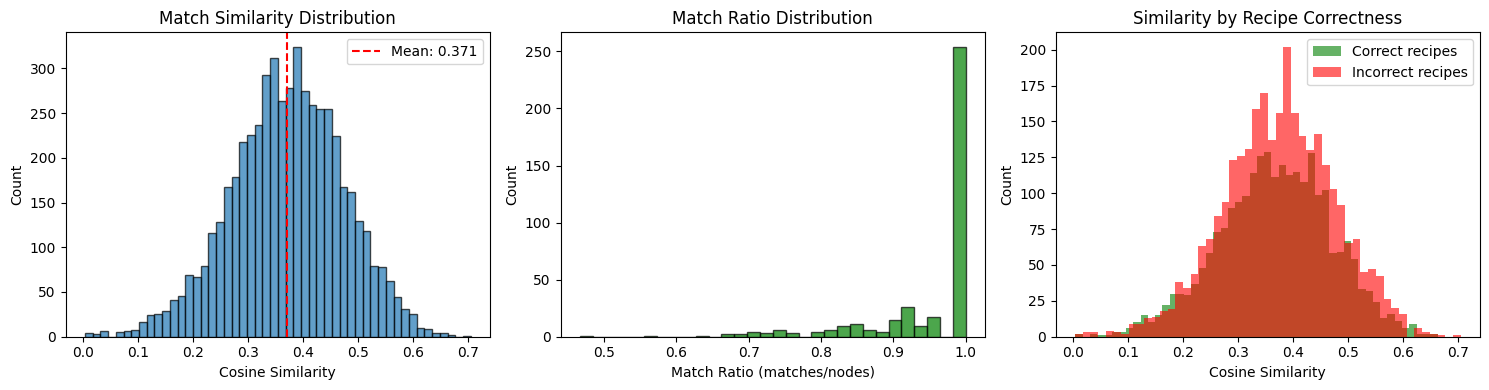


Matching Statistics (gt boundaries):
  Average similarity: 0.371
  Average match ratio: 95.34%
  Correct recipes avg sim: 0.367
  Incorrect recipes avg sim: 0.374


In [13]:
import matplotlib.pyplot as plt

# Numeric summary for every source; the plots below show the primary source only.
print(f"{'source':<14}{'graphs':>8}{'mean sim':>10}{'match ratio':>13}"
      f"{'sim | correct':>15}{'sim | error':>13}")
print("-" * 73)
for _source, _graphs in REALIZED_BY_SOURCE.items():
    _sims, _ratios, _ok, _err = [], [], [], []
    for _g in _graphs.values():
        _s = _g['match_similarities'][_g['node_matched']]
        _sims.extend(_s)
        _ratios.append(_g['num_matches'] / _g['num_nodes'])
        (_ok if _g['recipe_label'] == 0 else _err).extend(_s)
    print(f"{_source:<14}{len(_graphs):>8}{np.mean(_sims):>10.3f}{np.mean(_ratios):>12.2%}"
          f"{np.mean(_ok):>15.3f}{np.mean(_err):>13.3f}")
print()

# Matching statistics
all_similarities = []
match_ratios = []
correct_sims = []
incorrect_sims = []

for g in realized_graphs.values():
    sims = g['match_similarities'][g['node_matched']]
    all_similarities.extend(sims)
    match_ratios.append(g['num_matches'] / g['num_nodes'])

    if g['recipe_label'] == 0:
        correct_sims.extend(sims)
    else:
        incorrect_sims.extend(sims)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Match similarity distribution
axes[0].hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Cosine Similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Match Similarity Distribution')
axes[0].axvline(np.mean(all_similarities), color='r', linestyle='--',
                label=f'Mean: {np.mean(all_similarities):.3f}')
axes[0].legend()

# Match ratio distribution
axes[1].hist(match_ratios, bins=30, edgecolor='black', alpha=0.7, color='green')
axes[1].set_xlabel('Match Ratio (matches/nodes)')
axes[1].set_ylabel('Count')
axes[1].set_title('Match Ratio Distribution')

# Similarity by recipe correctness
axes[2].hist(correct_sims, bins=50, alpha=0.6, label='Correct recipes', color='green')
axes[2].hist(incorrect_sims, bins=50, alpha=0.6, label='Incorrect recipes', color='red')
axes[2].set_xlabel('Cosine Similarity')
axes[2].set_ylabel('Count')
axes[2].set_title('Similarity by Recipe Correctness')
axes[2].legend()

plt.tight_layout()
plt.savefig('extension_data/matching_analysis.png', dpi=150)
plt.show()

print(f"\nMatching Statistics ({PRIMARY_SOURCE} boundaries):")
print(f"  Average similarity: {np.mean(all_similarities):.3f}")
print(f"  Average match ratio: {np.mean(match_ratios):.2%}")
print(f"  Correct recipes avg sim: {np.mean(correct_sims):.3f}")
print(f"  Incorrect recipes avg sim: {np.mean(incorrect_sims):.3f}")

## 6a. Did Hungarian pick the *correct* nodes?

The match ratio reported above is not a measure of matching quality. Hungarian pads the
cost matrix to a square and returns `min(num_visual_steps, num_nodes)` assignments, so
`num_matches / num_nodes` is a step-count ratio: it says how many segments there were
relative to how many the recipe defines, and says nothing about whether "crack the egg"
was matched to the crack-the-egg node or to the whisk-the-egg node.

Under the annotated boundaries that question is answerable. Every visual segment then
corresponds to a known annotated step with a `step_id`, and every graph node carries the
same `step_id`, so the assignment can be scored directly. Three numbers are reported:

- **assignment accuracy** - the fraction of matched segments sent to the node with their
  own `step_id`. This is what Hungarian actually achieves.
- **top-1 retrieval** - the fraction whose own node is simply the nearest by cosine,
  ignoring the one-to-one constraint. Comparing the two says whether the constraint helps
  (it resolves near-duplicate descriptions) or hurts (it displaces a confident match).
- **chance** - one over the number of nodes, averaged over recordings.

Predicted boundaries are excluded here by construction: a detected segment has no ground
truth `step_id`, so accuracy is undefined for that source. Read this section as an upper
bound on matching quality, measured where it can be measured.


In [14]:
# ==============================================================================
# Hungarian assignment accuracy against ground-truth step ids
# ==============================================================================
ACCURACY_SOURCE = 'gt'

if ACCURACY_SOURCE not in SOURCE_DATA:
    print(f"'{ACCURACY_SOURCE}' embeddings not loaded - assignment accuracy needs the "
          f"annotated boundaries and is skipped.")
else:
    n_assign_ok = n_assign = 0
    n_top1_ok = n_top1 = 0
    chance_rates = []
    skipped_len, skipped_id = [], []
    per_recipe = defaultdict(lambda: [0, 0])

    for recording_id, data in SOURCE_DATA[ACCURACY_SOURCE].items():
        recipe_id = str(data['recipe_id'])
        if recipe_id not in task_graph_embeddings:
            continue

        # The description filter here must be the one Substep 1 used, or embedding i and
        # step i are different steps and every number below is meaningless.
        steps = _valid_steps(recording_id)
        visual_emb = np.asarray(data['step_embeddings'])
        if len(steps) != len(visual_emb):
            skipped_len.append(recording_id)
            continue

        visual_step_ids = [s.get('step_id') for s in steps]
        if any(sid is None for sid in visual_step_ids):
            skipped_id.append(recording_id)
            continue

        graph = task_graph_embeddings[recipe_id]
        node_step_ids = [n['step_id'] for n in graph['nodes']]
        text_emb = graph['embeddings']
        chance_rates.append(1.0 / max(len(node_step_ids), 1))

        matches, _, _ = hungarian_matching(visual_emb, text_emb)
        for v_idx, t_idx, _sim in matches:
            n_assign += 1
            hit = int(node_step_ids[t_idx] == visual_step_ids[v_idx])
            n_assign_ok += hit
            per_recipe[recipe_id][0] += hit
            per_recipe[recipe_id][1] += 1

        # Unconstrained nearest node, for the same segments.
        similarity = compute_similarity_matrix(visual_emb, text_emb)
        for v_idx, t_idx in enumerate(similarity.argmax(axis=1)):
            n_top1 += 1
            n_top1_ok += int(node_step_ids[t_idx] == visual_step_ids[v_idx])

    print(f"Scored {n_assign} assignments over "
          f"{len(SOURCE_DATA[ACCURACY_SOURCE])} recordings "
          f"({ACCURACY_SOURCE} boundaries)")
    if skipped_len:
        print(f"  skipped, descriptions not aligned with embeddings: {len(skipped_len)} "
              f"{skipped_len[:4]}")
    if skipped_id:
        print(f"  skipped, missing step_id: {len(skipped_id)}")

    if n_assign:
        print()
        print(f"  Hungarian assignment accuracy : {n_assign_ok / n_assign:.2%}")
        print(f"  Unconstrained top-1 retrieval : {n_top1_ok / max(n_top1, 1):.2%}")
        print(f"  Chance (1 / num_nodes)        : {np.mean(chance_rates):.2%}")

        rows = sorted(((ok / max(tot, 1), rid, tot) for rid, (ok, tot) in per_recipe.items()))
        print(f"\n  Worst 5 recipes   " + "  ".join(f"{rid}:{acc:.0%}" for acc, rid, _ in rows[:5]))
        print(f"  Best 5 recipes    " + "  ".join(f"{rid}:{acc:.0%}" for acc, rid, _ in rows[-5:]))
        print("""
Read this together with the match ratio above. The ratio counts assignments; this counts
correct ones. Whatever gap exists between them is matching error that every later substep
inherits, and it bounds how much of Substep 4's score can come from the graph rather than
from the step count.""")


Scored 5358 assignments over 384 recordings (gt boundaries)

  Hungarian assignment accuracy : 35.91%
  Unconstrained top-1 retrieval : 27.12%
  Chance (1 / num_nodes)        : 7.46%

  Worst 5 recipes   5:12%  3:17%  18:23%  25:25%  10:26%
  Best 5 recipes    21:47%  17:49%  9:49%  4:50%  12:52%

Read this together with the match ratio above. The ratio counts assignments; this counts
correct ones. Whatever gap exists between them is matching error that every later substep
inherits, and it bounds how much of Substep 4's score can come from the graph rather than
from the step count.


## 7. Save Realized Graphs

In [15]:
# Save realized graphs for Substep 4 - one file per boundary source.
OUTPUT_DIR = "extension_data"
os.makedirs(OUTPUT_DIR, exist_ok=True)

text_encoder_type = 'egovlp' if EGOVLP_AVAILABLE else 'sentence-transformers-fallback'

OUTPUT_NAMES = {'gt': 'realized_task_graphs.pkl',
                'actionformer': 'realized_task_graphs_actionformer.pkl'}

for source, graphs in REALIZED_BY_SOURCE.items():
    save_data = {
        'realized_graphs': graphs,
        'task_graph_embeddings': task_graph_embeddings,
        'splits': SOURCE_SPLITS[source],
        'config': {
            'feature_dim': FEATURE_DIM,
            'text_encoder': text_encoder_type,
            'text_encoder_aligned': EGOVLP_AVAILABLE,
            'matching': 'hungarian',
            'embedding_source': source,
            'task_graph_source': ('captaincook4d_dag' if 'source_file' in
                                  next(iter(task_graphs.values())) else 'linear_chain'),
            # Flag for Substep 4 to check before it builds node features. A .pkl
            # written before this section existed carries neither the execution ranks
            # nor the violation counts, and a model reading one would silently lose
            # the order signal again with nothing to indicate it.
            'stores_execution_order': True,
        }
    }
    name = OUTPUT_NAMES.get(source, f"realized_task_graphs_{source}.pkl")

    targets = [os.path.join(OUTPUT_DIR, name)]
    if IN_COLAB:
        drive_dir = "/content/drive/MyDrive/AML_Project/extension_data"
        os.makedirs(drive_dir, exist_ok=True)
        targets.append(os.path.join(drive_dir, name))

    for path in targets:
        with open(path, 'wb') as f:
            pickle.dump(save_data, f)
    print(f"  {source:<14} {len(graphs):>3} graphs -> {', '.join(targets)}")

print(f"\nText encoder: {text_encoder_type} (aligned: {EGOVLP_AVAILABLE})")
print(f"Task graph structure: {save_data['config']['task_graph_source']}")


  gt             384 graphs -> extension_data/realized_task_graphs.pkl, /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs.pkl
  actionformer   384 graphs -> extension_data/realized_task_graphs_actionformer.pkl, /content/drive/MyDrive/AML_Project/extension_data/realized_task_graphs_actionformer.pkl

Text encoder: egovlp (aligned: True)
Task graph structure: captaincook4d_dag


## 8. Visualize Sample Graph

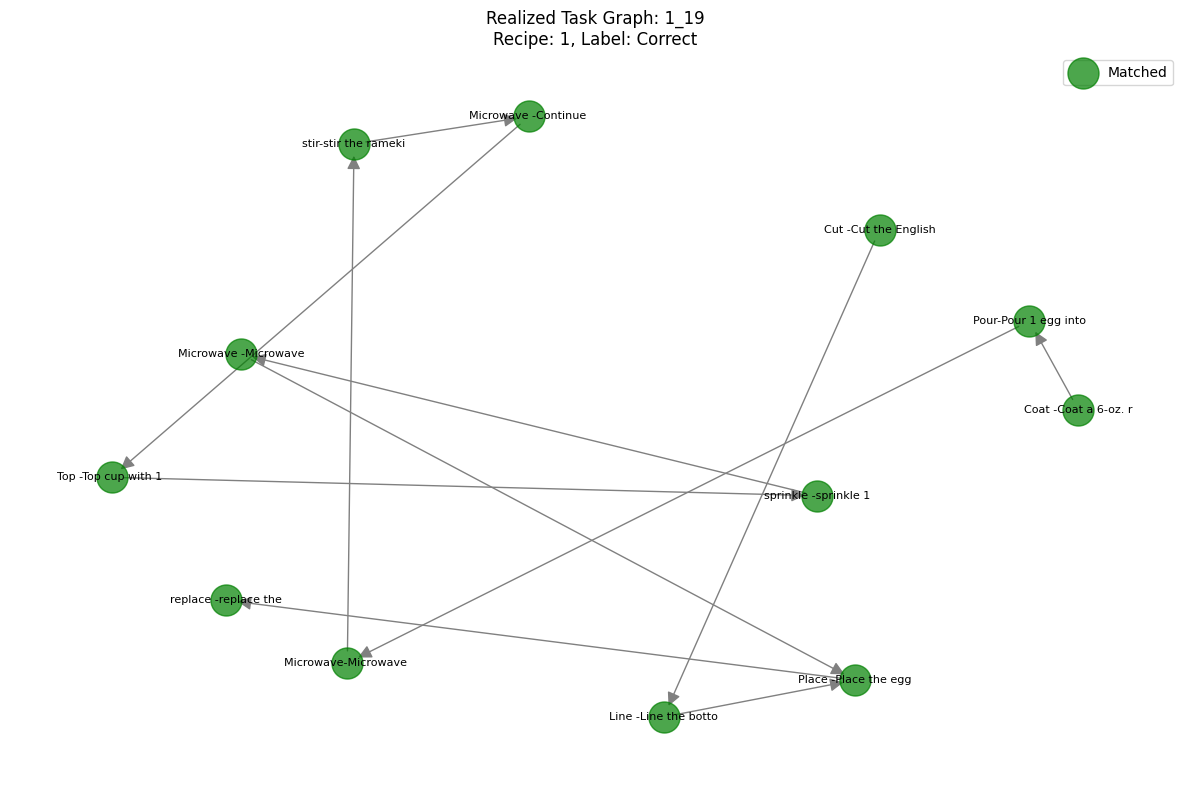

In [16]:
try:
    import networkx as nx

    # Visualize a sample realized graph
    sample_id = list(realized_graphs.keys())[0]
    sample_graph = realized_graphs[sample_id]
    sample_recipe = sample_graph['recipe_id']

    # Create NetworkX graph
    G = nx.DiGraph()

    nodes = task_graph_embeddings[sample_recipe]['nodes']
    for i, node in enumerate(nodes):
        matched = sample_graph['node_matched'][i]
        sim = sample_graph['match_similarities'][i]
        G.add_node(i, label=node['description'][:20], matched=matched, sim=sim)

    for edge in task_graph_embeddings[sample_recipe]['edges']:
        G.add_edge(edge['from'], edge['to'])

    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))

    pos = nx.spring_layout(G, k=2)

    # Color nodes by match status
    matched_nodes = [n for n in G.nodes() if G.nodes[n]['matched']]
    unmatched_nodes = [n for n in G.nodes() if not G.nodes[n]['matched']]

    nx.draw_networkx_nodes(G, pos, nodelist=matched_nodes, node_color='green',
                           node_size=500, alpha=0.7, label='Matched')
    nx.draw_networkx_nodes(G, pos, nodelist=unmatched_nodes, node_color='red',
                           node_size=500, alpha=0.7, label='Unmatched')

    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)

    labels = {n: G.nodes[n]['label'] for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=8)

    plt.title(f"Realized Task Graph: {sample_id}\nRecipe: {sample_recipe}, Label: {'Incorrect' if sample_graph['recipe_label'] else 'Correct'}")
    plt.legend()
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('extension_data/sample_realized_graph.png', dpi=150)
    plt.show()

except ImportError:
    print("NetworkX not installed. Skip graph visualization.")

## Summary

Substep 3 encodes the CaptainCook4D task graphs and matches each recording's localized
steps onto them, producing one realized graph per recording per boundary source.

**What the notebook does**

1. Loads the 24 shipped per-recipe DAGs. A recipe whose graph cannot be resolved is a hard
   error - the linear-chain fallback is disabled, because step_id order is not dependency
   order and a run using it would look successful while training Substep 4 on the wrong
   topology.
2. Encodes every node description with the **EgoVLP text encoder**, so node embeddings
   share a space with the visual step embeddings from Substep 1.
3. **Verifies that shared space instead of assuming it** (diagnostic in Section 2).
4. Matches visual steps to nodes with the Hungarian algorithm, one-to-one.
5. Stores text and visual node features separately, plus the fixed 0.5/0.5 average as the
   no-projection baseline, and records where in the observed sequence each matched step
   occurred.
6. Scores the assignment against ground-truth step ids (Section 6a).

**Why the EgoVLP text encoder**: the spec requires it because EgoVLP's text and video
towers are jointly trained and therefore aligned, which is what makes a raw cosine
similarity between a video segment and a step description meaningful. Any other text
encoder (e.g. plain DistilBERT) would sit in an unrelated space and would need a
projection learned from scratch.

**Verifying that claim**: `load_state_dict(..., strict=False)` silently leaves any
parameter missing from the checkpoint randomly initialised, so "the encoder loaded" is not
evidence the *aligned* head loaded. The diagnostic checks both: the checkpoint matches the
model exactly (0 missing, 0 unexpected keys), and video->text retrieval of each recording's
own step descriptions runs far above its chance rate, with matched pairs scoring clearly
above mismatched pairs. The alignment is real but far from perfect, which is the honest
characterisation of the matching quality this extension is built on.

**The learnable projection lives in Substep 4.** The spec asks that matched nodes be
updated with "a learnable projection of the node features and the visual features". There
is no loss in this notebook to train one with, so a projection instantiated here would be
a random untrained MLP. The text and visual blocks are therefore handed over separately and
`LearnableProjection` - the first module of every Substep 4 model, trained end-to-end by
the classification loss - performs the update. The fixed 0.5/0.5 average saved here is the
parameter-free control that ablation compares against; it does **not** satisfy the
requirement on its own.

**Execution order is preserved.** Matching alone writes visual features onto canonical
nodes and leaves the canonical edges unchanged, so "A then B" and "B then A" realize
identically. Order Error is the largest category in CaptainCook4D - 795 instances across
117 of 384 recordings - so each matched node now also carries its position in the observed
sequence (`execution_rank`), its segment boundaries, and the count of canonical edges its
position contradicts (`node_order_violations`). The canonical DAG is kept as the structure
being judged; the observed chain is stored alongside it, never in place of it.

**Key observations**

- Hungarian gives an optimal one-to-one assignment under the cosine similarity, and
  Section 6a reports how often that assignment is the *correct* node rather than merely a
  node. The match ratio is not that number: because the cost matrix is padded to a square,
  `num_matches / num_nodes` is a step-count ratio.
- An unmatched node means no localized segment was assigned to an expected step. Under the
  annotated boundaries that closely tracks genuine omission; under predicted boundaries it
  conflates omission with a detector miss, under-segmentation and matching ambiguity. The
  two readings are not interchangeable and the results report both sources for that reason.
- Mean match similarity alone does **not** separate correct from incorrect executions. This
  is expected rather than a defect: CaptainCook4D errors are mostly wrong temperature,
  wrong quantity, a reordering or a missing step, which barely change how much a performed
  step looks like its description. The usable signal is in the per-node features, the
  unmatched mask and the order violations, which is what the GNN consumes.

**Next**: **Substep 4** - GNN classification of the realized task graph, where the
learnable projection is trained end-to-end with the classification loss.
